# Noisy baseline model: predicting temporal AIT activity from static I-JEPA features

## Main idea

This notebook predicts the complete temporal AIT population response to a static image using a frozen I-JEPA representation and a small trainable temporal decoder. The model does not receive a video or any other temporal input. Instead, it learns a sequence of temporal queries that extracts a different mixture of either whole I-JEPA layers or individual embedding features at each neural-response time point. During training, an independent Gaussian perturbation is added to the temporal embeddings for every image.

The central hypothesis is therefore:

> Does selecting individual I-JEPA embedding features, rather than mixing layers only as wholes, improve prediction of temporal AIT population responses?

The complete pipeline is:

```text
Static image
    |
    +-- Frozen I-JEPA ViT-H/14, or cached I-JEPA activations
    |
    v
Three layer representations [B, 3, 1280]
    |
    +-- layer mode: project three whole layer vectors
    +-- feature mode: expose 3 x 1280 embedding coordinates
    |
Learned coarse temporal embeddings [T/R, E_te]
    +-- independent Gaussian noise per image during training
    |
    v
Attention at each coarse time block
    +-- layer weights   [B, T/R, 3]
    +-- feature weights [B, T/R, 3, 1280]
    |
    v
Coarse latent representation [B, T/R, V]
    |
    v
Block upsampling MLP -> fine latents [B, T, V]
    |
    v
Pointwise neural MLP + one readout per target bin
    |
    v
Predicted AIT activity [B, T, neurons]
```

## Current configuration

The configuration uses monkey `three0`, session `250313`, area `AIT`, and stimulus set `talia_20each_tizi`. Neural activity is taken from `natraster` between 0 and 300 ms and resampled from 1000 Hz to 10 Hz, deliberately producing three coarse 100-millisecond bins for this initial experiment. The resulting data contain 776 stimuli and 25 AIT channels.

The visual backbone is I-JEPA ViT-H/14 at an input resolution of 224 x 224 pixels. Mean-pooled representations are taken from encoder layers 4, 17, and 27, matching the established I-JEPA configuration used elsewhere in this project. Each selected layer contributes a 1280-dimensional vector. The current run uses cached activations with shape `[776, 3, 1280]`; raw-image input is also supported.

Training uses a batch size of 128, a 20% validation fraction, 300 epochs, AdamW with learning rate `1e-3` and weight decay `1e-4`, and dropout `0.5`. The temporal embedding and value dimensions are both 128, while the hidden dimension of the two decoder MLPs is 32. `attention_granularity` selects `"layer"` or `"feature"`; the current configuration uses feature-level attention. Temporal-embedding noise has a relative standard deviation of `1.0` and is disabled during evaluation.

## 1. Neural-data loading and alignment

The neural loaders return activity with shape `[neurons, time, samples]`. Two source formats are supported:

- `natraster`, used for the model targets, contains unique-image averaged responses. It loads the requested temporal window, converts the data to `float32`, selects the requested brain-area channels, resamples the signal, and aligns its stimulus dimension to the `ImageFolder` ordering. The configured result has shape `[25, 3, 776]`.
- `raster` contains repeated single trials. It loads neural data in chunks, reads the filename associated with each trial, and maps every occurrence to the corresponding source image. Repeated presentations remain separate neural samples.

Even when `natraster` supplies the prediction targets, the configured repeated `raster` is loaded to estimate target reliability. This file contains 16--23 repetitions per stimulus. Only training-image identities contribute to the loss weights.

Stimulus alignment is an essential part of the pipeline. `neural_image_indices` maps every neural sample to the correct row of the image dataset or cached activation array. The notebook checks that the number of mappings agrees with the neural sample dimension and that every mapped index is valid.

## 2. Visual inputs and frozen I-JEPA features

Images are indexed through `torchvision.datasets.ImageFolder`. `ProcessorTransform` applies the preprocessing recipe saved with the Hugging Face checkpoint, and the notebook verifies that the processor returns the configured 224 x 224 spatial resolution. Class labels created by `ImageFolder` are not used.

There are two input modes:

- With `training_input_mode="activations"`, the loader returns precomputed features with shape `[layers, embedding] = [3, 1280]`. This is the efficient default because the backbone is frozen.
- With `training_input_mode="images"`, the loader returns a processed image with shape `[3, 224, 224]`. I-JEPA is then run online under `torch.no_grad()`, and forward hooks collect the selected layer outputs.

In both modes, I-JEPA is used only as a fixed feature extractor. All its parameters have `requires_grad=False`, and the model overrides `train()` so that the backbone remains in evaluation mode while the decoder is trained.

## 3. Dataset and DataLoaders

`NeuralInputDataset` joins each visual input to its neural target. It transposes neural activity from `[neurons, time, samples]` to `[samples, time, neurons]`. A sample therefore contains either cached features `[3, 1280]` or an image `[3, 224, 224]`, together with a target `[3, 25]`.

The class performs early checks for invalid modes, missing cached activations, incorrect tensor dimensions, mismatches between neural trials and image mappings, and indices outside the source image dataset.

The train/validation split is made over unique image identities rather than directly over trials. This is important in `raster` mode: every repeated presentation of one image is kept in the same partition, preventing image leakage. The executed split contains 621 training images and 155 validation images. Training batches are shuffled; validation batches are not.

## 4. Model architecture

### Frozen encoder

The encoder is a 32-block I-JEPA ViT-H/14 with embedding dimension 1280. Three intermediate layer representations are retained. The trainable network operates on these representations rather than modifying the backbone.

### Layer-level and feature-level attention inputs

The model supports two attention granularities. `attention_granularity="layer"` preserves the original architecture: each 1280-dimensional layer vector is projected into one key and one value of dimension 128:

```text
layer features X: [B, 3, 1280]
keys K:           [B, 3, 128]
values V:         [B, 3, 128]
```

With `attention_granularity="feature"`, the attention axis instead contains all `3 * 1280 = 3840` individual embedding coordinates. Every layer-feature coordinate has its own learned 128-dimensional key direction. Its I-JEPA activation modulates that key, making feature selection stimulus-dependent. Attention gates the normalized feature vector, which is then projected from 3840 coordinates into the 128-dimensional value space. These are embedding/channel features from the mean-pooled layer output, not spatial patch tokens.

### Noisy temporal queries and configurable attention

The network learns one base query for every coarse neural-time block. For `T` target bins and compression ratio `R`, it uses `T / R` queries; `T` must be divisible by `R`. During training, `TemporalNoiseBaselineModel` broadcasts the query table across the batch and gives every image an independent Gaussian perturbation. The configured noise scale is relative to the current standard deviation of the learned embedding table. Evaluation remains deterministic because `temporal_noise_in_eval=False`. Attention weights are also stimulus-dependent because the keys are computed from the current image.

In layer mode, scaled dot-product attention is computed over the three I-JEPA layers:

$$A_{btl} = \operatorname{softmax}_l\left(\frac{Q_t K_{bl}^{T}}{\sqrt{d_k}}\right).$$

In feature mode, the same query scores every layer-feature coordinate and the softmax is taken jointly over all 3840 coordinates:

$$A_{btle} = \operatorname{softmax}_{l,e}\left(\frac{Q_t K_{ble}^{T}}{\sqrt{d_k}}\right).$$

The resulting feature weights have shape `[B, T/R, 3, 1280]`. They multiplicatively gate the corresponding I-JEPA coordinates before projection into one latent vector per coarse block. Neither mode attends over time; temporal coupling is introduced only inside the subsequent non-overlapping upsampling blocks.

### Coarse-to-fine temporal features and per-bin neural readouts

The temporal feature MLP is `Linear(V, H) -> GELU -> Dropout -> Linear(H, R * V)`. Each coarse attended vector is therefore expanded into `R` ordered fine-time latent vectors. Coarse blocks remain independent, but the `R` fine bins inside one block are derived jointly from the same attention query and coarse latent.

After reshaping the expanded blocks to `[B, T, V]`, a shared pointwise feature MLP, `Linear(V, H) -> GELU -> Dropout`, processes every fine-time latent. The existing readout loop then applies a separate `Linear(H, neurons)` head to each target bin. Head `t` sees only fine latent `t`, and its weights receive loss gradients only from neural target `t`. The final output has shape `[B, T, neurons]`. The frozen I-JEPA parameters are excluded from optimization.

## 5. Meaning of temporal modelling in this baseline

The model is temporal in its output parameterization, but it is neither recurrent nor autoregressive. All three time points are predicted simultaneously. There is no RNN, GRU, LSTM, temporal self-attention, or state passed from one time point to the next.

Temporal structure is generated by the coarse learned queries, the block upsampling MLP, and the time-specific readouts. Different coarse blocks can select different mixtures of whole I-JEPA layers or individual embedding coordinates. Within a block, `R` fine bins share one attention selection but receive distinct latent coordinates and distinct readout heads. The model remains non-recurrent: compression introduces block-local coupling, not temporal state evolution.


## 6. Loss function

For every target time `t` and neuron `n`, the repeated raster is randomly split
within each training stimulus. Responses are averaged within each half, and the
two stimulus-preference vectors are correlated across images. Averaging the
half-split correlations, applying the Spearman--Brown correction, and taking
its square root gives the `stim_r` ceiling $r_{tn}$.

The configured temperature $\tau$ maps these reliability scores to mean-one
softmax weights over the $C$ time--neuron target cells:

$$w_{tn}=C\,\frac{\exp(r_{tn}/\tau)}
{\sum_{t',n'}\exp(r_{t'n'}/\tau)}.$$

High temperature approaches uniform weighting; low temperature concentrates
the loss on the most reliable cells. The aligned squared errors are then
averaged with these weights:

$$\mathcal{L}=\frac{\sum_{t,n}w_{tn}
\left[\frac{1}{B}\sum_b(\hat y_{btn}-y_{btn})^2\right]}
{\sum_{t,n}w_{tn}}.$$

Prediction cell `(t,n)` is compared only with target cell `(t,n)`. There is no
temporal shifting or cross-time comparison, and only training-image identities
contribute to the reliability estimate.

## 7. Optimization and training loop

AdamW receives only parameters for which `requires_grad=True`: temporal embeddings, layer projections or feature keys/value projection, normalization parameters, decoder MLPs, and an optional query projection. I-JEPA parameters are excluded.

During one training epoch, the notebook:

1. Sets the decoder to training mode while keeping I-JEPA in evaluation mode.
2. Moves inputs and neural targets to the selected device.
3. Runs the forward pass and computes the aligned loss separately for every time bin.
4. Backpropagates the loss.
5. Applies one AdamW update.
6. Clears gradients with `zero_grad(set_to_none=True)`.
7. Accumulates the batch loss weighted by its number of samples.

The gradient reset occurs after each optimizer step, with an initial reset before training. This is valid, although resetting immediately before the forward pass is the more common convention. There is no learning-rate scheduler, gradient clipping, mixed-precision training, early stopping, or model checkpointing.

## 8. Validation and diagnostics

The randomly initialized decoder is evaluated before the first update. After every training epoch, the complete validation set is evaluated with the model in evaluation mode and gradient tracking disabled. A fixed validation example is plotted every ten epochs; prediction and target are averaged across neurons to leave one temporal trajectory. This plot is intuitive but can hide channel-specific errors.

After training, attention weights are collected for all validation images. Layer mode is plotted directly. In feature mode, weights are averaged across the 1280 coordinates of each target layer and renormalized over layers; this is equivalent to plotting each layer's total attention mass and keeps the heatmap comparable with layer mode. The result shows whether early and late neural predictions rely on different I-JEPA depths, while raw `[image, time, layer, feature]` weights remain available for finer analysis.

## 9. Ridge-regression reference

The notebook also fits a simpler linear reference. The three I-JEPA vectors are concatenated into 3840 input features, while the complete neural response is flattened into 75 outputs (`3 time bins * 25 neurons`). Ridge regression is fitted on the same image-grouped training split and evaluated with the same self-consistency-weighted loss.

The imported implementation uses `RidgeCV` over ten candidate alphas from `1e-6` to `1e3`. The later notebook description calls this a fixed-alpha ridge model, but the implementation actually performs alpha selection on the training data.

## 10. Results in the saved execution

The saved outputs below were produced with the preceding DINOv3 shared-readout `BaselineModel` and must be regenerated after switching the backbone to I-JEPA and the decoder to `TemporalNoiseBaselineModel`. In that preceding run, the randomly initialized model started at validation MSE `0.065310`; ridge obtained `0.045250`; and the neural model reached approximately `0.044928` around epoch 33. These numbers are retained only as a historical reference and are not results for the current noisy I-JEPA architecture.

The feature-attention architecture must be rerun before it can be compared with layer attention or ridge. For a fair comparison, run both attention granularities with the same image split and random initialization seed. The notebook still does not retain the best validation checkpoint, so the final model need not be the best model encountered during training.

## 11. Strengths and current limitations

Important strengths are explicit alignment checks, image-grouped data splitting, training-only split-half reliability weights, efficient cached-feature training, careful freezing of I-JEPA, configurable layer/feature attention, and comparison against a strong linear reference. The same model can use cached activations during training and raw images during inference.

The main limitations are:

- There is one train/validation split and no independent test set or cross-validation.
- NumPy controls the split seed, but PyTorch initialization, dropout, and DataLoader shuffling are not fully seeded.
- There is no early stopping or best-model checkpoint.
- The objective emphasizes reliable stimulus preferences but does not normalize response variance within each output cell.
- There is no temporal smoothness or biologically motivated latency constraint.
- Compression couples fine bins within each non-overlapping block, but there is no interaction between blocks or recurrent state.
- The model can reveal changing layer preferences, but cannot establish whether recurrent state evolution is required to explain AIT dynamics.

This makes the notebook a useful, interpretable baseline for later comparisons with recurrent, state-space, or temporally interacting models.

In [ ]:
import os
import sys
from dataclasses import dataclass, field
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

# Put this repository first so another project's package cannot shadow it.
project_src_path = str((PROJECT_ROOT / "python_scripts" / "src").resolve())
useful_stuff_path = str(Path(paths["useful_stuff_path"]).resolve())
for source_path in (useful_stuff_path, project_src_path):
    while source_path in sys.path:
        sys.path.remove(source_path)
    # end while source path is already registered
    sys.path.insert(0, source_path)
# end for source path

# Reimport the development loader even if an older copy is kernel-cached.
sys.modules.pop("project_specific_utils.dataloader", None)
sys.modules.pop("project_specific_utils", None)
import project_specific_utils.dataloader as neural_dataloader
expected_dataloader_path = (
    Path(project_src_path) / "project_specific_utils" / "dataloader.py"
).resolve()
loaded_dataloader_path = Path(neural_dataloader.__file__).resolve()
if loaded_dataloader_path != expected_dataloader_path:
    raise ImportError(
        f"Expected neural loader {expected_dataloader_path}, loaded "
        f"{loaded_dataloader_path}."
    )
# end if a different project's loader was imported

# from II_analyses.static_encoding import (
#     compute_static_prediction_II,
#     fit_static_projection,
# )
from project_specific_utils.dataloader import (
    load_img_natraster,
    load_img_raster,
    make_neural_input_loader,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)
from IT_recap.hf_feature_extraction import (
    ProcessorTransform,
    is_valid_image_file,
    load_hf_layer_features,
)
from IT_recap.neural_prediction_training import (
    aggregate_attention_by_layer,
    collect_concatenated_layer_regression_data,
    neural_activity_weighted_mse_loss,
    plot_mean_channel_reconstruction,
    split_half_reliability,
    test_step,
    training_step,
)
from IT_recap.tvsd_consistency import (
    consistency_weights,
    describe_weights,
    temperature_label,
)
# Reload the development model after local source edits in this kernel.
sys.modules.pop('model_classes.temporal_models', None)
from model_classes.temporal_models import TemporalNoiseBaselineModel
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.image_processing.computational_models import imgANN

In [ ]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    # Paul natraster example: source="natraster", monkey="paul",
    # date="230204", folder="fewer_occlusion".
    neural_data_source: str = "natraster"  # "raster" or "natraster"
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    raster_file: str = "rasters_three0_250313to21.mat" # None #"paul_nat" #
    raster_key: str = "rasters"
    raster_image_names_file: str = "allimages_three0_250313to21.mat"
    raster_image_names_key: str = "allimages"
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0
    time_end_ms: float = 300.0
    raster_chunk_size: int = 512
    self_consistency_resamples: int = 40
    # Softmax temperature over time-neuron reliability scores.
    temperature: float = 0.1
    # pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "ijepa_vith14_1k"
    model_source: str = "facebook/ijepa_vith14_1k"
    img_size: int = 224
    use_fast_processor: bool = False
    pkg = "hf"
    layer_names: list[str] = field(default_factory=lambda: [
        "encoder.layer.4.output.dense",
        "encoder.layer.17.output.dense",
        "encoder.layer.27.output.dense",
    ])
    pooling: str = "mean"
    trust_remote_code = True
    attn_implementation = "sdpa"
    # Use "images" if cached I-JEPA features do not exist for folder_name.
    training_input_mode: str = "activations"  #"images" # "images" or "activations"

    batch_size = 256
    validation_fraction: float = 0.2
    random_seed: int = 0
    epochs: int = 500
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    temporal_embedding_dim: int = 256
    temporal_noise_std: float = .5
    relative_temporal_noise: bool = True
    temporal_noise_in_eval: bool = False
    value_dim: int = 128
    temporal_compression_ratio: int = 1
    # "layer" attends over three layer vectors; "feature" attends over
    # every embedding coordinate within each selected layer.
    attention_granularity: str = "feature"
    mlp_hidden_dim: int = 32
    dropout: float = 0.3
    reconstruction_plot_interval: int = 250
    reconstruction_sample_index: int = 10
    
# EOC


cfg = Cfg()
cfg

## Load and align the static spaces

The neural data are shaped `(neurons, timepoints, samples)`. With `neural_data_source="raster"`, samples are repeated single trials and their explicit presentation names determine the image mapping. With `neural_data_source="natraster"`, samples are unique-image averages and the ordering follows `run_static_dRSA.py`: `load_img_natraster` plus `map_image_order_from_ann_to_monkey`. Cached I-JEPA features remain in ImageFolder source order.

In [30]:
# Load the preprocessing recipe saved with the Hugging Face checkpoint.
image_processor = AutoImageProcessor.from_pretrained(
    cfg.model_source,
    use_fast=cfg.use_fast_processor,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    transform=ProcessorTransform(image_processor),
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

# Fail early if the checkpoint processor and configured model size disagree.
sample_image, _ = dataset[0]
sample_shape = tuple(sample_image.shape[-2:])
if sample_shape != (cfg.img_size, cfg.img_size):
    raise ValueError(
        f"Processor returned {sample_shape}, expected "
        f"{(cfg.img_size, cfg.img_size)}."
    )
# end if processor output size differs from model input size

# Align neural samples to ImageFolder following the appropriate source format.
if cfg.neural_data_source == "raster":
    raster, neural_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    neural_image_indices = map_trial_image_order_to_ann(
        neural_image_names,
        dataset,
    )
elif cfg.neural_data_source == "natraster":
    # Match run_static_dRSA.py: natraster rows follow sorted unique names.
    raster = load_img_natraster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        date=cfg.date,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
    )
    neural_image_indices = np.asarray(
        map_image_order_from_ann_to_monkey(
            paths,
            cfg.monkey_name,
            cfg.date,
            dataset,
        ),
        dtype=int,
    )
else:
    raise ValueError(
        "neural_data_source must be either 'raster' or 'natraster'."
    )
# end if repeated raster or averaged natraster is requested

raster_array = raster.get_array()

if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, trials), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3

if len(neural_image_indices) != raster_array.shape[2]:
    raise ValueError(
        f"Found {len(neural_image_indices)} aligned images but "
        f"{raster_array.shape[2]} neural samples."
    )
# end if neural data and image ordering differ

# Reliability needs repetitions. Reuse raster targets directly when they
# are the training targets; otherwise load the configured repeated raster.
if cfg.neural_data_source == "raster":
    self_consistency_raster_array = raster_array
    self_consistency_image_indices = neural_image_indices.copy()
else:
    self_consistency_raster, self_consistency_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    self_consistency_raster_array = self_consistency_raster.get_array()
    self_consistency_image_indices = map_trial_image_order_to_ann(
        self_consistency_image_names,
        dataset,
    )
# end if the training source already contains repeated trials

if self_consistency_raster_array.shape[:2] != raster_array.shape[:2]:
    raise ValueError(
        "Repeated targets and training targets disagree in their "
        "[neurons, time] shape: "
        f"{self_consistency_raster_array.shape[:2]} and "
        f"{raster_array.shape[:2]}."
    )
# end if reliability targets do not align with model outputs

# Store repeated targets as [presentations, time, neurons] for split-half
# stimulus-preference correlations later, after the image split is known.
self_consistency_trial_targets = self_consistency_raster_array.transpose(
    2, 1, 0
)

# Cached I-JEPA outputs are needed only when bypassing the frozen backbone.
precomputed_layer_features = None
if cfg.training_input_mode == "activations":
    precomputed_layer_features = load_hf_layer_features(
        output_dir=Path(paths["data_path"]) / "models",
        dataset_name=cfg.folder_name,
        model_name=cfg.model_name,
        img_size=cfg.img_size,
        layer_names=cfg.layer_names,
        pooling=cfg.pooling,
    )
    if precomputed_layer_features.shape[0] != len(dataset):
        raise ValueError(
            "Cached features and ImageFolder have different image counts: "
            f"{precomputed_layer_features.shape[0]} and {len(dataset)}."
        )
    # end if cached features and ImageFolder are misaligned
elif cfg.training_input_mode != "images":
    raise ValueError(
        "training_input_mode must be either 'images' or 'activations'."
    )
# end if cached features are requested

print(f"{cfg.neural_data_source} neural data: {raster_array.shape}")
print(f"Aligned unique stimuli: {len(np.unique(neural_image_indices))}")
print(
    "Repeated trials for self-consistency: "
    f"{len(self_consistency_trial_targets)}"
)
if precomputed_layer_features is not None:
    print(f"Cached I-JEPA features: {precomputed_layer_features.shape}")
else:
    print("Training input: images (I-JEPA runs online)")
# end if cached features were loaded


natraster neural data: (25, 30, 776)
Aligned unique stimuli: 776
Repeated trials for self-consistency: 14840
Cached I-JEPA features: (776, 3, 1280)


In [31]:
# NeuralInputDataset is implemented in project_specific_utils.dataloader.


In [32]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.img_size,
    pooling=cfg.pooling,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.model_source,
    trust_remote_code=cfg.trust_remote_code,
)

19:16:16 - device being used: mps


In [33]:
# Change cfg.training_input_mode to switch the training input source.
loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=neural_image_indices,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=torch.device(ann.get_device()).type == "cuda",
)


In [34]:
# TemporalNoiseBaselineModel is implemented in model_classes.temporal_models.


## Temperature-controlled self-consistency-weighted neural-activity loss

For every `(time, neuron)` target cell, repeated responses to each training
stimulus are split in half and averaged. The two stimulus-preference vectors
are correlated, averaged across resamples, and Spearman--Brown corrected. The
square root of this reliability is the stimulus-correlation ceiling
$r_{tn}\in[0,1]$ returned by `split_half_reliability`.

The new loss temperature converts these reliabilities into positive softmax
weights over all $C$ time--neuron cells:

$$
w_{tn}=C\,\frac{\exp(r_{tn}/\tau)}
{\sum_{t',n'}\exp(r_{t'n'}/\tau)}.
$$

The weights have mean one. A high temperature approaches ordinary MSE; a low
temperature concentrates optimization on the most reliable target cells. The
aligned weighted loss remains

$$
\mathcal{L}=\frac{\sum_{t,n}w_{tn}
\left[\frac{1}{B}\sum_b(\hat y_{btn}-y_{btn})^2\right]}
{\sum_{t,n}w_{tn}}.
$$

Reliability is estimated using training-image identities only. No temporal
shifting, averaging across bins, or validation-image preference information is
used to construct the weights.

In [35]:
# neural_activity_weighted_mse_loss is implemented in IT_recap.neural_prediction_training.


# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss


In [36]:
# Training, validation, plotting, and ridge-data helpers are implemented in IT_recap.neural_prediction_training.


In [ ]:
# Reuse the same initialization seed when comparing attention modes.
torch.manual_seed(cfg.random_seed)
m = TemporalNoiseBaselineModel(
    ann,
    layers=cfg.layer_names,
    temporal_embedding_dim=cfg.temporal_embedding_dim,
    temporal_noise_std=cfg.temporal_noise_std,
    relative_noise=cfg.relative_temporal_noise,
    noise_in_eval=cfg.temporal_noise_in_eval,
    value_dim=cfg.value_dim,
    n_timepoints=raster_array.shape[1],
    temporal_compression_ratio=cfg.temporal_compression_ratio,
    n_neurons=raster_array.shape[0],
    mlp_hidden_dim=cfg.mlp_hidden_dim,
    dropout=cfg.dropout,
    attention_granularity=cfg.attention_granularity,
).to(ann.get_device())
m

In [ ]:
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if validation fraction is invalid

# Split unique images first, then assign all their repeated trials together.
full_dataset = loader.dataset
unique_image_indices = np.unique(full_dataset.image_indices)
n_validation_images = max(
    1,
    round(len(unique_image_indices) * cfg.validation_fraction),
)
if n_validation_images >= len(unique_image_indices):
    raise ValueError("The validation split leaves no training images.")
# end if training image split is empty

split_rng = np.random.default_rng(cfg.random_seed)
shuffled_image_indices = split_rng.permutation(unique_image_indices)
validation_image_indices = shuffled_image_indices[:n_validation_images]
is_validation_trial = np.isin(
    full_dataset.image_indices,
    validation_image_indices,
)
training_trial_indices = np.flatnonzero(~is_validation_trial).tolist()
validation_trial_indices = np.flatnonzero(is_validation_trial).tolist()
training_dataset = Subset(full_dataset, training_trial_indices)
validation_dataset = Subset(full_dataset, validation_trial_indices)

# Confirm that repeated presentations never cross the split boundary.
training_image_indices = set(
    full_dataset.image_indices[training_trial_indices].tolist()
)
validation_image_indices = set(
    full_dataset.image_indices[validation_trial_indices].tolist()
)
if training_image_indices & validation_image_indices:
    raise RuntimeError("An image appears in both training and validation.")
# end if repeated images leaked across splits
print(
    f"split: {len(training_image_indices)} images / "
    f"{len(training_trial_indices)} trials for training; "
    f"{len(validation_image_indices)} images / "
    f"{len(validation_trial_indices)} trials for validation"
)

# Estimate one reliability weight for each target (time, neuron) cell.
# Only training-image identities enter this estimate, preventing target
# information from the validation stimulus preferences from leaking in.
if cfg.self_consistency_resamples <= 0:
    raise ValueError("self_consistency_resamples must be positive.")
# end if no split-half resamples were requested
self_consistency_training_mask = np.isin(
    self_consistency_image_indices,
    list(training_image_indices),
)
candidate_image_indices, candidate_repetition_counts = np.unique(
    self_consistency_image_indices[self_consistency_training_mask],
    return_counts=True,
)
eligible_image_indices = candidate_image_indices[
    candidate_repetition_counts >= 2
]
if len(eligible_image_indices) < 2:
    raise ValueError(
        "Self-consistency requires at least two training images with "
        "at least two repetitions each."
    )
# end if stimulus-preference correlation cannot be estimated

self_consistency_training_mask &= np.isin(
    self_consistency_image_indices,
    eligible_image_indices,
)
selected_self_consistency_image_indices = (
    self_consistency_image_indices[self_consistency_training_mask]
)
_, compact_self_consistency_image_ids = np.unique(
    selected_self_consistency_image_indices,
    return_inverse=True,
)
selected_self_consistency_targets = self_consistency_trial_targets[
    self_consistency_training_mask
]

# split_half_reliability returns the sqrt(r_SB) stim_r ceiling used by
# consistency_weights as the reliability score for each target cell.
stimulus_preference_ceiling = split_half_reliability(
    selected_self_consistency_targets,
    compact_self_consistency_image_ids,
    n_images=len(eligible_image_indices),
    reducer="mean",
    n_resamples=cfg.self_consistency_resamples,
    seed=cfg.random_seed,
)
self_consistency_reliability = np.nan_to_num(
    stimulus_preference_ceiling,
    nan=0.0,
    posinf=1.0,
    neginf=0.0,
).astype(np.float32)
self_consistency_weights = consistency_weights(
    self_consistency_reliability,
    temperature=cfg.temperature,
).astype(np.float32)
weight_description = describe_weights(
    self_consistency_weights,
    self_consistency_reliability,
)
print(
    "self-consistency weights [time, neurons] "
    f"{self_consistency_weights.shape} | "
    f"temperature {temperature_label(cfg.temperature)} | "
    f"effective cells {weight_description['n_effective_cells']:.1f}/"
    f"{self_consistency_weights.size} | "
    f"max/mean {weight_description['weight_max_over_mean']:.3f}"
)

pin_memory = torch.device(m.device).type == "cuda"
training_generator = torch.Generator()
training_generator.manual_seed(cfg.random_seed)
training_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=pin_memory,
    generator=training_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# Configure regression optimization over trainable parameters only.
optimizer = torch.optim.AdamW(
    m.get_trainable_parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)
self_consistency_weight_tensor = torch.as_tensor(
    self_consistency_weights,
    dtype=torch.float32,
    device=m.device,
)
cost_function = partial(
    neural_activity_weighted_mse_loss,
    weights=self_consistency_weight_tensor,
)
use_precomputed_features = full_dataset.input_mode == "activations"
optimizer.zero_grad(set_to_none=True)

# Fit plain ridge on the same image-grouped split used by the neural model.
ridge_training_features, ridge_training_targets = (
    collect_concatenated_layer_regression_data(
        m,
        training_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_validation_features, ridge_validation_targets = (
    collect_concatenated_layer_regression_data(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_encoding = linear_encoding(
    regression_type="ridge",
    cv_type="same",
)
ridge_encoding.fit(
    ridge_training_features,
    ridge_training_targets,
    transpose=False,
)
ridge_validation_predictions = ridge_encoding.predict(
    ridge_validation_features,
    transpose=False,
    transpose_output=False,
)
ridge_validation_cell_mse = np.mean(
    (ridge_validation_predictions - ridge_validation_targets).reshape(
        -1, raster_array.shape[1], raster_array.shape[0]
    ) ** 2,
    axis=0,
)
ridge_validation_mse = float(
    np.average(
        ridge_validation_cell_mse,
        weights=self_consistency_weights,
    )
)
print(
    "concatenated-layer ridge | self-consistency-weighted validation "
    f"{ridge_validation_mse:.6f}"
)

# Evaluate the randomly initialized trainable model before any update.
initial_validation_loss = test_step(
    m,
    validation_loader,
    cost_function,
    use_precomputed_features,
    device=m.device,
)
print(
    f"epoch 000/{cfg.epochs:03d} | weighted validation "
    f"{initial_validation_loss:.6f}"
)
if cfg.reconstruction_plot_interval <= 0:
    raise ValueError("reconstruction_plot_interval must be positive.")
# end if reconstruction plot interval is invalid
plot_mean_channel_reconstruction(
    m,
    validation_dataset,
    cfg.reconstruction_sample_index,
    epoch=0,
    use_precomputed_features=use_precomputed_features,
    time_start_ms=cfg.time_start_ms,
    sampling_frequency=cfg.new_fs,
    device=m.device,
)

# Run one validation pass after every complete training epoch.
training_losses = []
validation_losses = []
for epoch in range(1, cfg.epochs + 1):
    training_loss = training_step(
        m,
        training_loader,
        optimizer,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    validation_loss = test_step(
        m,
        validation_loader,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    print(
        f"epoch {epoch:03d}/{cfg.epochs:03d} | "
        f"weighted train {training_loss:.6f} | "
        f"weighted validation {validation_loss:.6f}"
    )

    # Show progress periodically and always include the final model.
    should_plot_reconstruction = (
        epoch % cfg.reconstruction_plot_interval == 0
        or epoch == cfg.epochs
    )
    if should_plot_reconstruction:
        plot_mean_channel_reconstruction(
            m,
            validation_dataset,
            cfg.reconstruction_sample_index,
            epoch=epoch,
            use_precomputed_features=use_precomputed_features,
            time_start_ms=cfg.time_start_ms,
            sampling_frequency=cfg.new_fs,
            device=m.device,
        )
    # end if reconstruction should be plotted
# end for epoch

torch.Size([256, 30, 25])


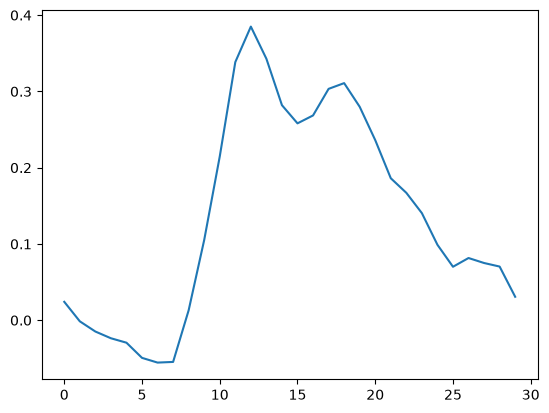

In [41]:
for i in training_loader:
    print(i[1].shape)
    y = i[1][:, :, 1].mean(dim=0)
    plt.plot(y.detach().cpu().numpy())
    break

## Training curves, ridge reference, and temporal layer attention

The black star is the self-consistency-weighted validation MSE of ridge regression using the selected I-JEPA layer vectors concatenated into one feature vector. Its final-epoch x-position is only for display; ridge is fitted once on the same image-grouped training split.

In [ ]:
# Average attention over all validation stimuli after training.
m.eval()
validation_attention = []
with torch.no_grad():
    for inputs, _ in validation_loader:
        inputs = inputs.to(m.device)
        _, attention_weights = m(
            inputs,
            use_precomputed_features=use_precomputed_features,
        )
        layer_attention = aggregate_attention_by_layer(
            attention_weights
        )
        validation_attention.append(layer_attention.cpu())
    # end for validation batch
# end with no gradient tracking

mean_layer_attention = torch.cat(validation_attention, dim=0).mean(dim=0)

# Attention is constant inside each fine-time block produced by one coarse query.
mean_fine_attention = mean_layer_attention.repeat_interleave(
    m.get_temporal_compression_ratio(),
    dim=0,
)

# Plot optimization error and the final validation-set attention schedule.
training_epochs = np.arange(1, len(training_losses) + 1)
validation_epochs = np.arange(0, len(validation_losses) + 1)
all_validation_losses = np.asarray(
    [initial_validation_loss, *validation_losses]
)
best_validation_index = int(np.argmin(all_validation_losses))
best_validation_epoch = int(validation_epochs[best_validation_index])
best_validation_loss = float(
    all_validation_losses[best_validation_index]
)
print(
    f"{cfg.attention_granularity} attention | best validation "
    f"{best_validation_loss:.6f} at epoch {best_validation_epoch:03d}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(
    training_epochs,
    training_losses,
    marker="o",
    label="Training weighted MSE",
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker="o",
    label="Validation weighted MSE",
)
axes[0].scatter(
    best_validation_epoch,
    best_validation_loss,
    marker="D",
    s=70,
    zorder=4,
    label=(
        f"Best {cfg.attention_granularity} weighted MSE "
        f"({best_validation_loss:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_validation_mse,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=(
        "Concatenated-layer ridge weighted MSE "
        f"({ridge_validation_mse:.4f})"
    ),
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Self-consistency-weighted MSE")
axes[0].set_title("Neural prediction error")
axes[0].grid(alpha=0.3)
axes[0].legend()

attention_image = axes[1].imshow(
    mean_fine_attention.T.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
axes[1].set_xlabel("Neural time-step index")
axes[1].set_ylabel("I-JEPA layer")
axes[1].set_title(
    f"Mean validation {cfg.attention_granularity} attention by layer"
)
axes[1].set_yticks(np.arange(len(m.get_layer_names())))
axes[1].set_yticklabels(m.get_layer_names())
attention_label = (
    "Layer attention weight"
    if cfg.attention_granularity == "layer"
    else "Normalized mean feature weight"
)
fig.colorbar(attention_image, ax=axes[1], label=attention_label)
fig.tight_layout()
plt.show()
